##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class**

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [10]:
#import libraries
!pip install -q tensorflow tensorflow_hub opencv-python matplotlib pillow

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [31]:
# Load the pre-trained Mask R-CNN model
model = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"
instance_detector = hub.load(model)

print("Mask R-CNN Model is sucessfully loaded.")

Mask R-CNN Model is sucessfully loaded.


In [32]:
# COCO class names
COCO_LABELS = {
    1: "person", 2: "bicycle", 3: "car", 4: "motorcycle", 5: "airplane",
    6: "bus", 7: "train", 8: "truck", 9: "boat", 10: "traffic light",
    11: "fire hydrant", 13: "stop sign", 14: "parking meter", 15: "bench",
    16: "bird", 17: "cat", 18: "dog", 19: "horse", 20: "sheep",
    21: "cow", 22: "elephant", 23: "bear", 24: "zebra", 25: "giraffe",
    27: "backpack", 28: "umbrella", 31: "handbag", 32: "tie", 33: "suitcase",
    34: "frisbee", 35: "skis", 36: "snowboard", 37: "sports ball",
    38: "kite", 39: "baseball bat", 40: "baseball glove", 41: "skateboard",
    42: "surfboard", 43: "tennis racket", 44: "bottle", 46: "wine glass",
    47: "cup", 48: "fork", 49: "knife", 50: "spoon", 51: "bowl",
    52: "banana", 53: "apple", 54: "sandwich", 55: "orange", 56: "broccoli",
    57: "carrot", 58: "hot dog", 59: "pizza", 60: "donut", 61: "cake",
    62: "chair", 63: "couch", 64: "potted plant", 65: "bed", 67: "dining table",
    70: "toilet", 72: "tv", 73: "laptop", 74: "mouse", 75: "remote",
    76: "keyboard", 77: "cell phone", 78: "microwave", 79: "oven",
    80: "toaster", 81: "sink", 82: "refrigerator", 84: "book", 85: "clock",
    86: "vase", 87: "scissors", 88: "teddy bear", 89: "hair drier",
    90: "toothbrush"
}

In [33]:
# My chosen 5 image paths
image_paths = [
    "/content/image1.jpg",
    "/content/image2.avif",
    "/content/image3.jpg",
    "/content/image4.jpg",
    "/content/image5.jpg"
]

print("Number of images:", len(image_paths))

Number of images: 5


In [34]:
# Loading image and preparing it
def load_image(path):
    image = Image.open(path).convert("RGB")
    return np.array(image)

In [39]:
# Run Mask R-CNN model on image
def perform_segmentation_inference(image_array):
    input_data = tf.convert_to_tensor(image_array)
    input_data = input_data[tf.newaxis, ...]

    # Run model prediction
    predictions = instance_detector(input_data)

    # Extract outputs and convert to numpy
    output_results = {
        'boxes': predictions['detection_boxes'][0].numpy(),
        'labels': predictions['detection_classes'][0].numpy().astype(int),
        'scores': predictions['detection_scores'][0].numpy(),
        'masks': predictions['detection_masks'][0].numpy()
    }

    return output_results

In [40]:
# Process segmentation results (draw everything)

def apply_segmentation_overlay(image, predictions, threshold=0.5):

    h, w, _ = image.shape
    output = image.copy()

    for i in range(len(predictions['scores'])):

        # Skip low confidence detections
        if predictions['scores'][i] < threshold:
            continue

        # Generate random color
        color = np.random.randint(0, 255, size=3).tolist()

        # Get box coordinates
        ymin, xmin, ymax, xmax = predictions['boxes'][i]
        x1, x2 = int(xmin * w), int(xmax * w)
        y1, y2 = int(ymin * h), int(ymax * h)

        # Get label name
        class_name = COCO_LABELS.get(predictions['labels'][i], "Object")
        label = f"{class_name}: {int(predictions['scores'][i] * 100)}%"

        # Draw bounding box
        cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)

        # Draw text
        cv2.putText(output, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Process mask
        mask = predictions['masks'][i]
        mask_resized = cv2.resize(mask, (x2 - x1, y2 - y1))
        mask_binary = (mask_resized > 0.5)

        roi = output[y1:y2, x1:x2]
        color_arr = np.array(color, dtype=np.uint8)

        # Apply mask overlay
        if mask_binary.any():
            roi[mask_binary] = (roi[mask_binary] * 0.5 + color_arr * 0.5).astype(np.uint8)

    return output

In [41]:
# Display function

def show_segmentation_result(image, title="Segmentation Result"):

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')
    plt.title(title)
    plt.show()


Processing Image 1: /content/image1.jpg


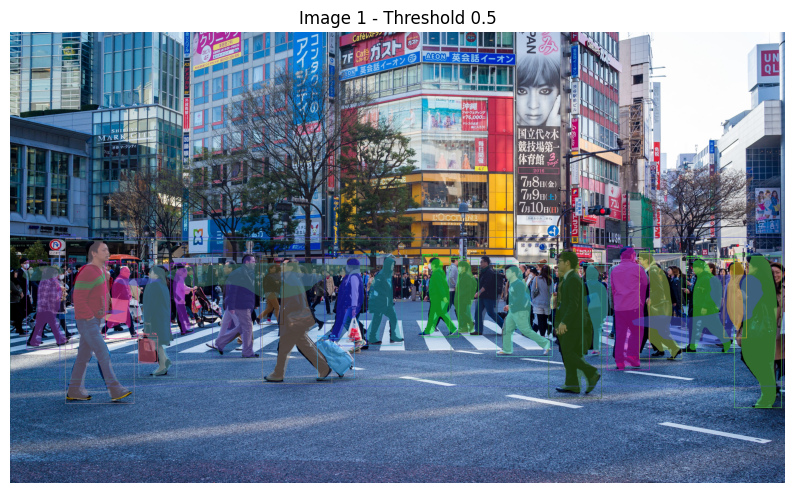


Processing Image 2: /content/image2.avif


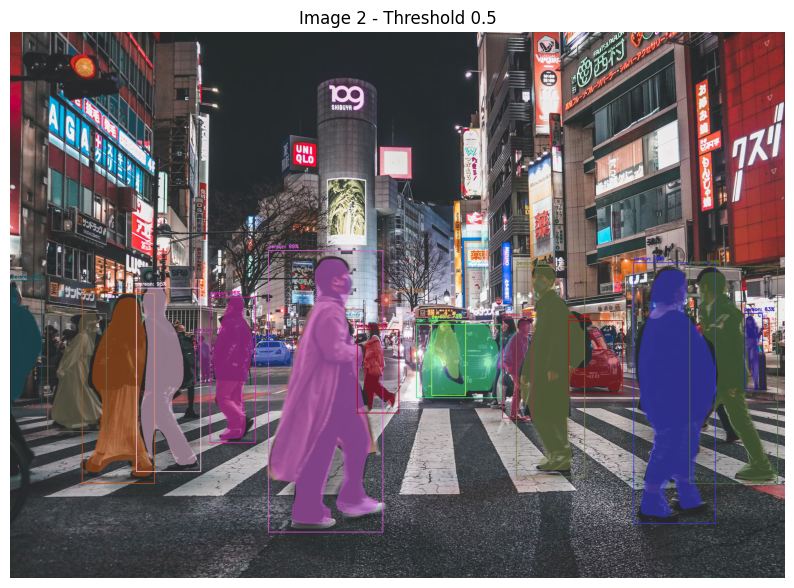


Processing Image 3: /content/image3.jpg


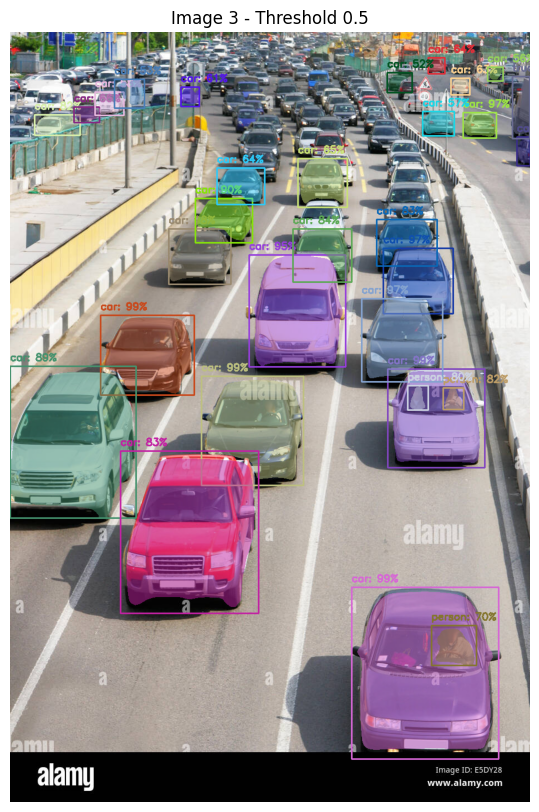


Processing Image 4: /content/image4.jpg


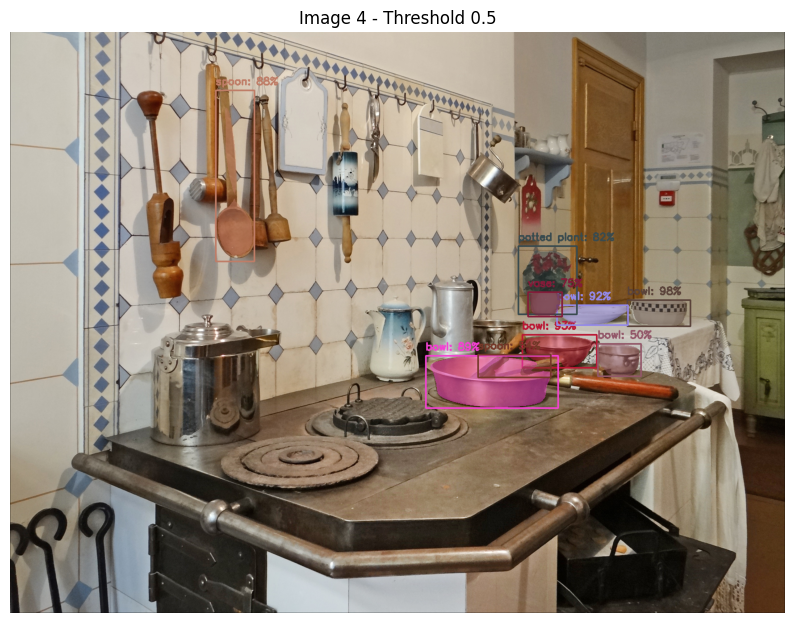


Processing Image 5: /content/image5.jpg


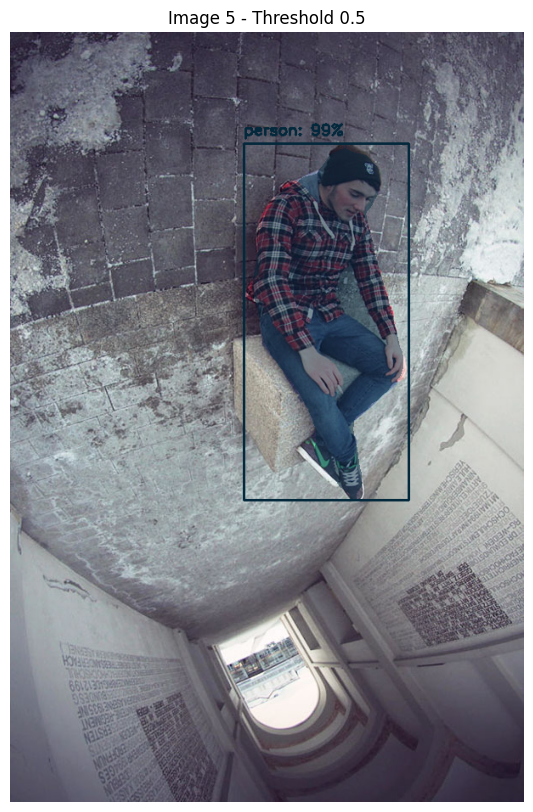

In [43]:
# Run segmentation on all images with threshold = 0.5

for idx, img_path in enumerate(image_paths):

    print(f"\nProcessing Image {idx+1}: {img_path}")

    img = load_image(img_path)

    preds = perform_segmentation_inference(img)

    result = apply_segmentation_overlay(img, preds, threshold=0.5)

    show_segmentation_result(result, title=f"Image {idx+1} - Threshold 0.5")


Processing Image 1: /content/image1.jpg


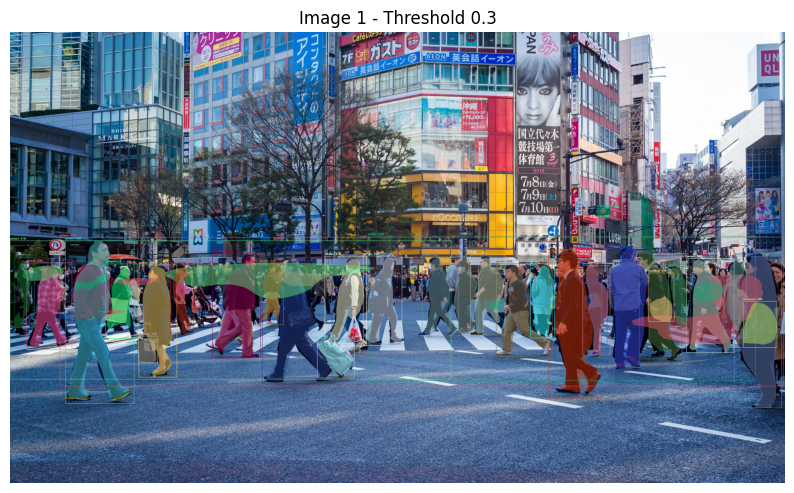


Processing Image 2: /content/image2.avif


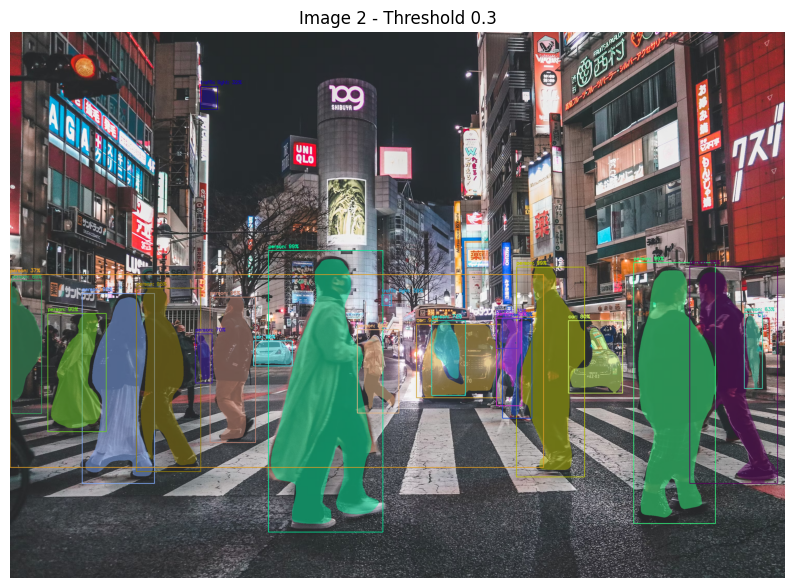


Processing Image 3: /content/image3.jpg


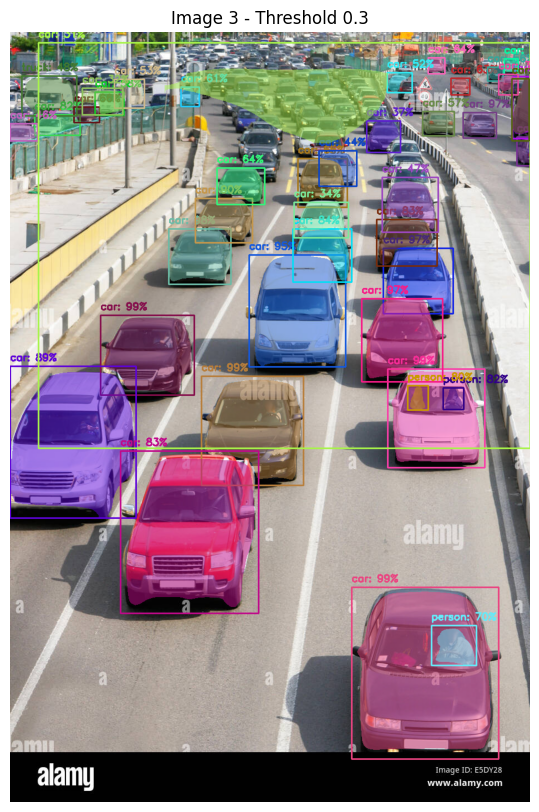


Processing Image 4: /content/image4.jpg


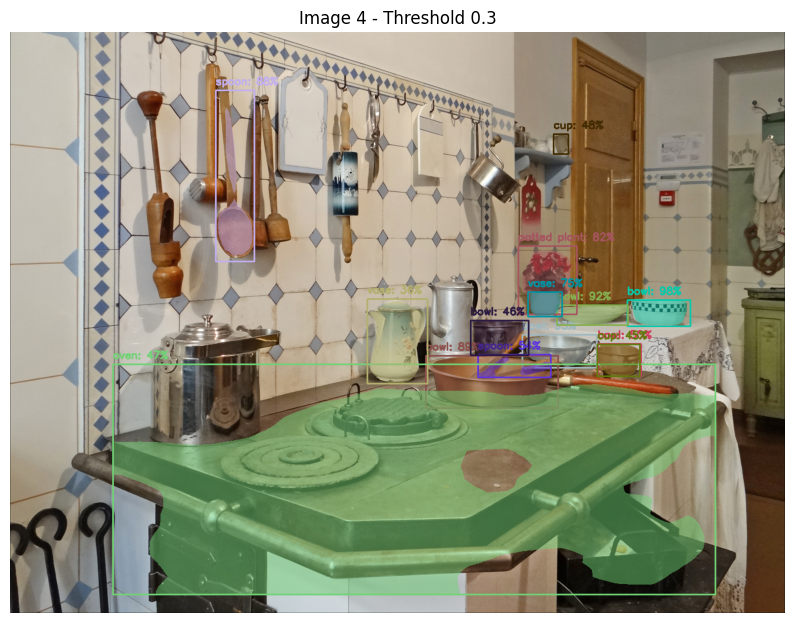


Processing Image 5: /content/image5.jpg


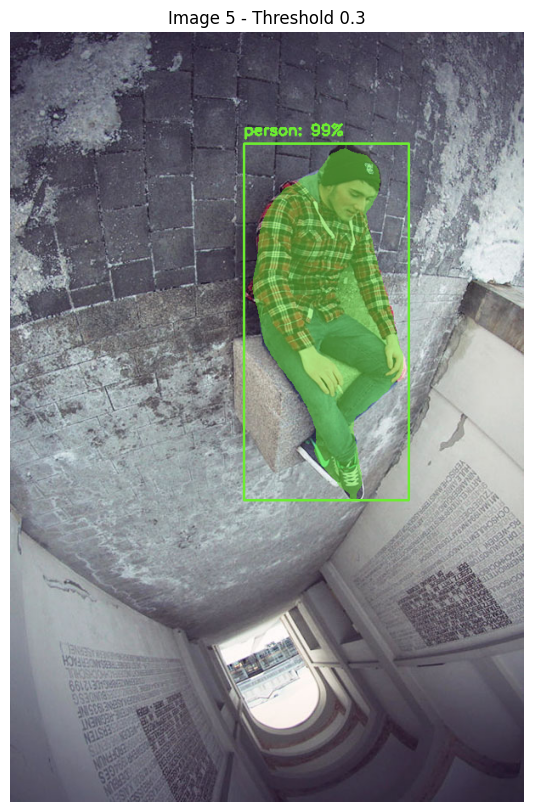

In [44]:
# Run segmentation on all images with threshold = 0.3

for idx, img_path in enumerate(image_paths):

    print(f"\nProcessing Image {idx+1}: {img_path}")

    img = load_image(img_path)

    preds = perform_segmentation_inference(img)

    result = apply_segmentation_overlay(img, preds, threshold=0.3)

    show_segmentation_result(result, title=f"Image {idx+1} - Threshold 0.3")